<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula23a_cost_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

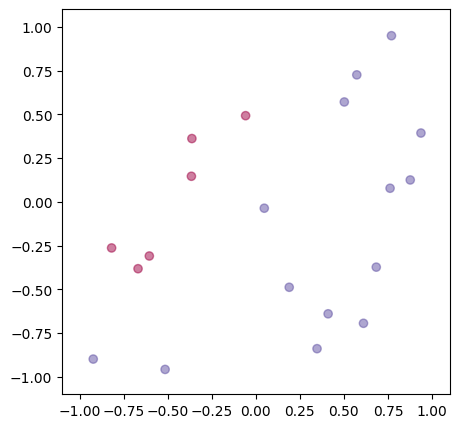

In [79]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, vector=[1,-1], bias=0.2):
  X = np.random.uniform(size=(n,2))*2-1
  y = (X@vector + bias>0)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-1.1, 1.1)
  plt.ylim(-1.1, 1.1)

plotDataset(X, y)
plt.show()

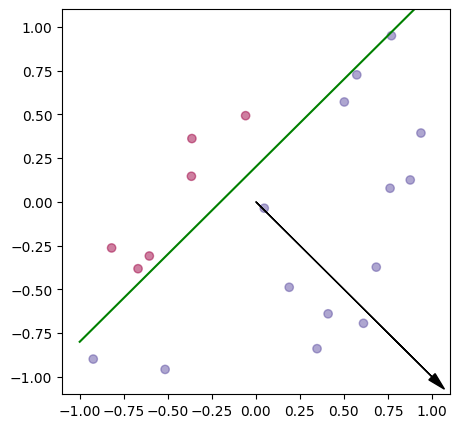

In [80]:
def plotHyperplan(vector, bias):
  xs = np.array([-1,1])
  ys = -(vector[0]*xs + bias)/vector[1]
  plt.plot(xs, ys, 'g')

def plotVector(vector):
  plt.arrow(0, 0, vector[0], vector[1], head_width=0.05, head_length=0.1, fc='k', ec='k')

plotDataset(X, y)
vector = [1,-1]
bias = 0.2
plotHyperplan(vector, bias)
plotVector(vector)
plt.show()

In [81]:
from abc import ABC, abstractmethod

class CostFunction(ABC):
  @abstractmethod
  def getCost(self, y, y_pred):
    pass
  @abstractmethod
  def getGradient(self, y, y_pred, X):
    pass

class WidrowHoff(CostFunction):
  def getCost(self, y, y_pred):
    return np.mean((y - y_pred)**2)
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - y_pred)

In [82]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, max_iter=1000, learning_rate=0.002, cost=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=(X.shape[1],))
    for _ in range(self.max_iter):
      y_pred = X @ w
      w += self.cost.getGradient(y, y_pred, X) * self.learning_rate
    return w

Accuracy: 0.95
Weights: [ 0.16602826  1.2931514  -0.77474267]


<Figure size 500x500 with 0 Axes>

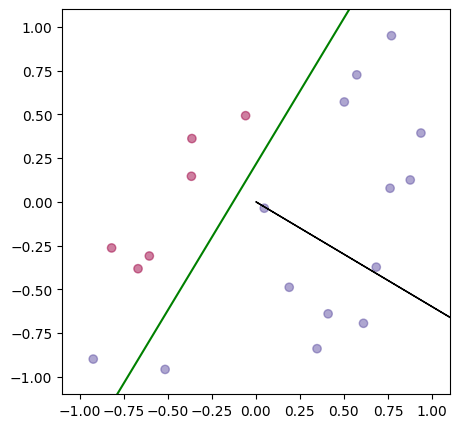

In [83]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

class ShallowNeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w = self.trainingAlgorithm.getW(X, y)
    return self

  def pre_activation(self, X):
    logits = X @ self.w
    return logits

  def predict(self, X):
    X = include_bias(X)
    logits = self.pre_activation(X)
    y_pred = np.sign(logits)
    return y_pred

model = ShallowNeuralNetwork(GradientDescent())
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

Accuracy: 1.0
Weights: [ 0.21819122  0.59398397 -0.37722986]


<Figure size 500x500 with 0 Axes>

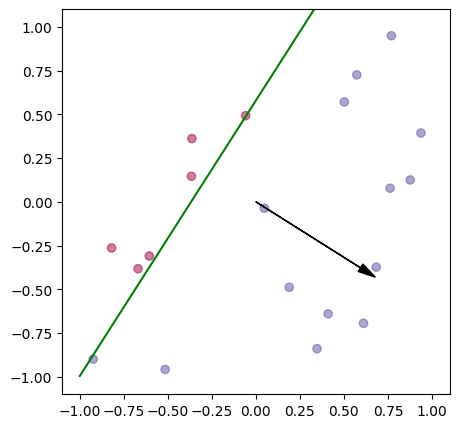

In [84]:
class SmoothSurrogate(CostFunction):
  def getCost(self, y, y_pred):
    error = y - np.sign(y_pred)
    return np.sqrt(np.sum(error**2))
  def getGradient(self, y, y_pred, X):
    error = y - np.sign(y_pred)
    return X.T @ error

model = ShallowNeuralNetwork(GradientDescent(cost=SmoothSurrogate()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

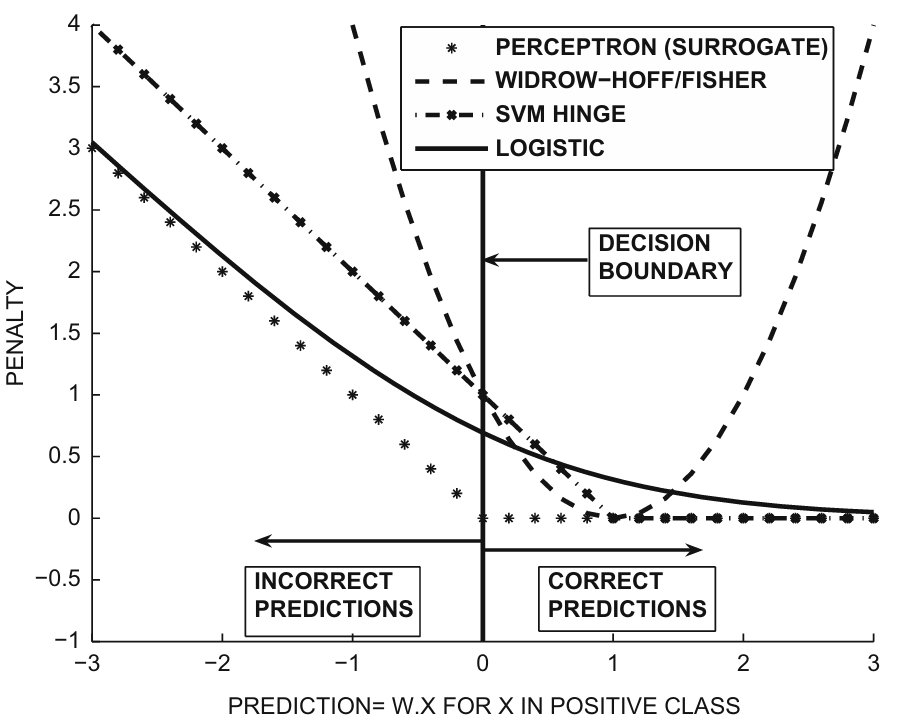

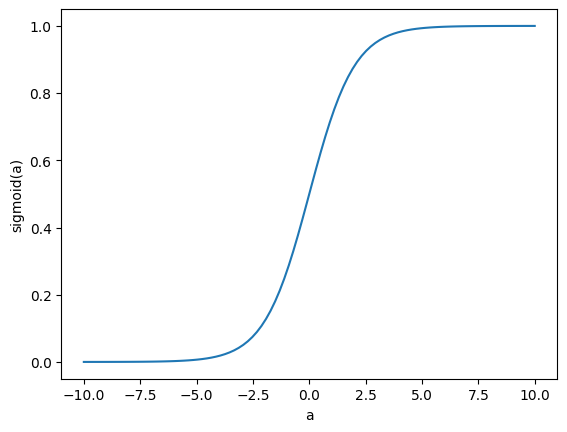

In [85]:
a = np.linspace(-10, 10, 100)
def sigmoid(a):
  return 1/(1+np.exp(-a))

plt.plot(a, sigmoid(a))
plt.xlabel('a')
plt.ylabel('sigmoid(a)')
plt.show()

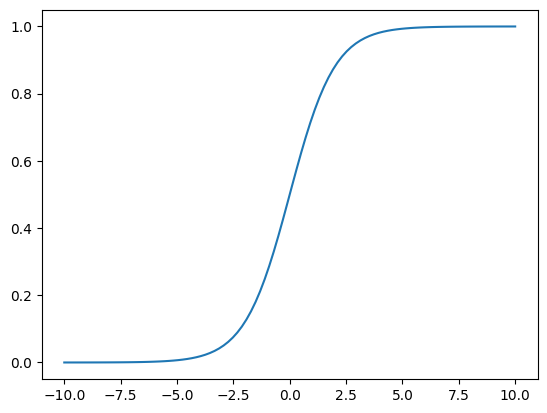

In [86]:
from scipy.special import expit

plt.plot(a, expit(a))
plt.show()

Accuracy: 0.75
Weights: [-2.30967374  7.10999414 -2.64407435]


<Figure size 500x500 with 0 Axes>

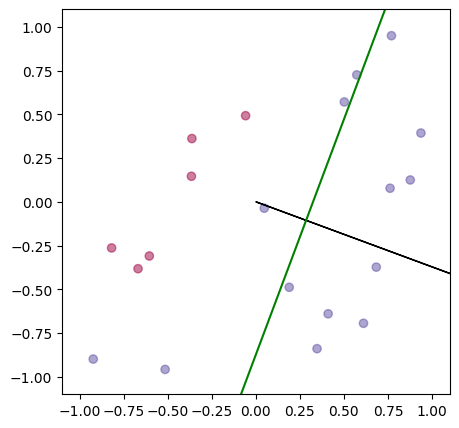

In [92]:
class LogLikehood(CostFunction):
  def getCost(self, y, y_pred):
    return np.sum(np.maximum(0, 1 - y * y_pred))
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - expit(y_pred))

model = ShallowNeuralNetwork(GradientDescent(cost=LogLikehood()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

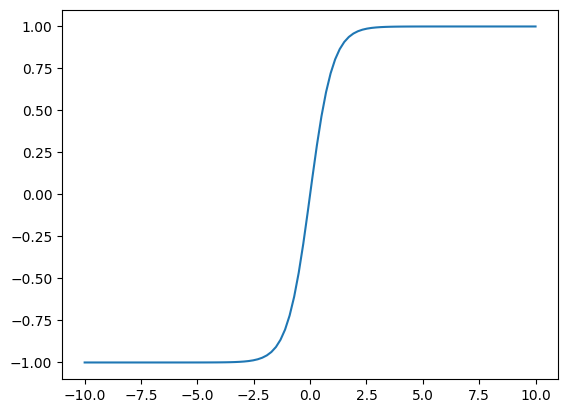

In [93]:
def tanh(a):
  return (np.exp(a)-np.exp(-a))/(np.exp(a)+np.exp(-a))

plt.plot(a, tanh(a))
plt.show()

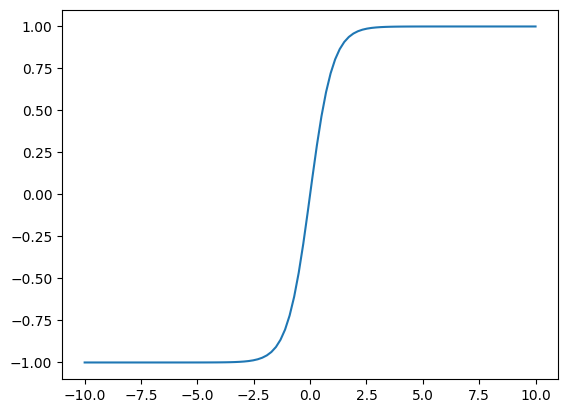

In [94]:
from numpy import tanh

plt.plot(a, tanh(a))
plt.show()

Accuracy: 0.95
Weights: [ 0.63906662  2.79334254 -1.98576749]


<Figure size 500x500 with 0 Axes>

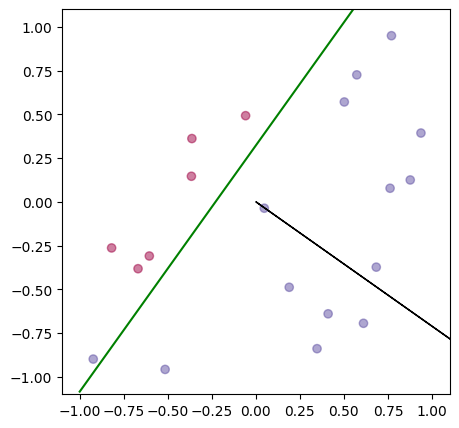

In [99]:
class LogLikehood(CostFunction):
  def getCost(self, y, y_pred):
    return np.sum(np.maximum(0, 1 - y * y_pred))
  def getGradient(self, y, y_pred, X):
    return X.T @ (y - np.tanh(y_pred))

model = ShallowNeuralNetwork(GradientDescent(cost=LogLikehood()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

Accuracy: 0.95
Weights: [ 0.59597133  3.47298585 -2.22851392]


<Figure size 500x500 with 0 Axes>

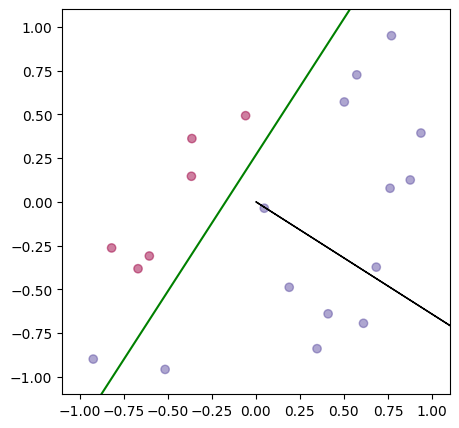

In [131]:
class HingeLoss(CostFunction):
  def getCost(self, y, y_pred):
    return np.sum(np.maximum(0, 1 - y * y_pred))
  def getGradient(self, y, y_pred, X):
    marginal_errors = (y * y_pred) < 1
    marginal_ys = np.copy(y)
    marginal_ys[~marginal_errors] = 0
    return X.T @ marginal_ys

model = ShallowNeuralNetwork(GradientDescent(cost=HingeLoss()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plotDataset(X, y)
plotHyperplan(model.w[1:], model.w[0])
plotVector(model.w[1:])
plt.show()

Accuracy: 1.0
Weights: [ 1.96340234  0.93414183 -0.85249153]


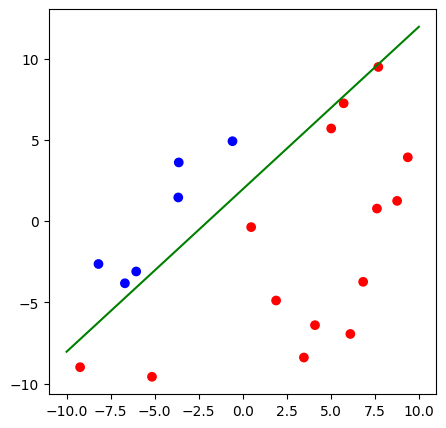

In [141]:
X10 = X*10

model = ShallowNeuralNetwork(GradientDescent(cost=HingeLoss()))
model.fit(X10, y)
y_pred = model.predict(X10)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w}")

plt.figure(figsize=(5,5))
plt.scatter(X10[:,0], X10[:,1], c=y, cmap="bwr")
vetor, bias = model.w[1:], model.w[0]
xs = np.array([-10,10])
ys = -(vector[0]*xs + bias)/vector[1]
plt.plot(xs, ys, 'g')
plt.show()